In [1]:
import pandas as pd
from pathlib import Path
import numpy as np

In [2]:
#Step 1 - load the counts tsv
DATA = Path("../../R_scripts_dea_gsea/results/files_for_python")

counts = pd.read_csv(DATA/"tcga_counts_01.tsv", sep="\t", index_col=0)
print("Counts:", counts.shape)

Counts: (63856, 304)


In [6]:
#Step 2 - strip Ensembl versions
orig_ids = counts.index.astype(str)

stripped_ids = (
    orig_ids
    .str.replace(r"\.\d+(?=_|$)", "", regex=True)
)

counts.index = stripped_ids



In [12]:
n_total = len(counts.index)
n_unique = counts.index.nunique()

print(f"Total rows: {n_total}")
print(f"Unique Ensembl IDs after stripping: {n_unique}")
print(f"Rows that will be collapsed: {n_total - n_unique}")


Total rows: 63856
Unique Ensembl IDs after stripping: 63856
Rows that will be collapsed: 0


In [8]:
par_y_ids = counts.index[counts.index.str.endswith("_PAR_Y")].unique()

print(f"Number of PAR_Y genes: {len(par_y_ids)}")
print("PAR_Y genes (first 10):")
print(par_y_ids[:10])


Number of PAR_Y genes: 45
PAR_Y genes (first 10):
Index(['ENSG00000228572_PAR_Y', 'ENSG00000182378_PAR_Y',
       'ENSG00000178605_PAR_Y', 'ENSG00000226179_PAR_Y',
       'ENSG00000167393_PAR_Y', 'ENSG00000275287_PAR_Y',
       'ENSG00000281849_PAR_Y', 'ENSG00000280767_PAR_Y',
       'ENSG00000234958_PAR_Y', 'ENSG00000229232_PAR_Y'],
      dtype='object')


In [11]:
print("PAR_Y genes:", counts.index.str.endswith("_PAR_Y").sum())
print("Any remaining versions:", counts.index.str.contains(r"\.\d+").any())


PAR_Y genes: 45
Any remaining versions: False


In [10]:
#Step 3 - collapse duplicates (if there are any)
counts = counts.groupby(counts.index).sum()

In [14]:
#Step 4 - compute library sizes per sample
lib_sizes = counts.sum(axis=0)

print("Library sizes:")
print(lib_sizes.head())

print("\nSummary:")
print(lib_sizes.describe())


Library sizes:
5c8c8a6e-40d4-4f82-ac3d-90cfdee15c0a    4.806134e+09
d9096909-1439-462d-b69c-cad1bf4f420c    8.831116e+09
29c17355-d646-48da-9e54-7b6dd85dd610    8.329708e+09
29bcba51-2580-473d-9cf7-bedbd0dbad1b    4.234438e+09
ad97b334-e034-4d33-a4d5-48c32d5d521c    4.856324e+09
dtype: float64

Summary:
count    3.040000e+02
mean     6.147412e+09
std      1.710131e+09
min      2.111016e+09
25%      4.982450e+09
50%      5.802621e+09
75%      7.469136e+09
max      1.179695e+10
dtype: float64


In [ ]:
#Check if all library sizes are above zero
assert (lib_sizes > 0).all()

In [ ]:
print("Min / max library size:", lib_sizes.min(), lib_sizes.max())

Min / max library size: 2111016125.0 11796953863.0


<Axes: title={'center': 'Library sizes per sample'}>

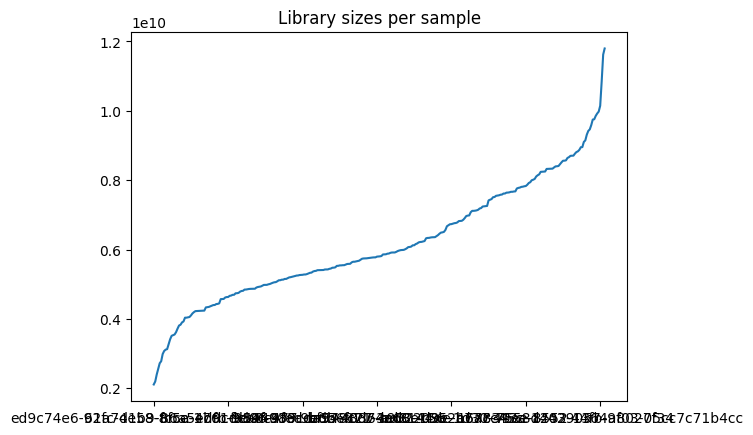

In [ ]:
lib_sizes.sort_values().plot(kind="line", title="Library sizes per sample")

In [18]:
#Step 5 - CPM
cpm = counts.div(lib_sizes, axis=1) * 1e6

In [19]:
#Step 6 - log2(CPM + 1)
logcpm = np.log2(cpm + 1)

In [20]:
assert np.isfinite(logcpm.values).all()
print("\nlogCPM summary (all values):")
print(pd.Series(logcpm.values.ravel()).describe())

print("\nExample (5 genes x 5 samples):")
print(logcpm.iloc[:5, :5])


logCPM summary (all values):
count    1.941222e+07
mean     1.257216e+00
std      2.152904e+00
min      0.000000e+00
25%      0.000000e+00
50%      2.286324e-02
75%      1.655953e+00
max      1.647950e+01
dtype: float64

Example (5 genes x 5 samples):
                 5c8c8a6e-40d4-4f82-ac3d-90cfdee15c0a  \
ENSG00000000003                              5.883855   
ENSG00000000005                              0.053913   
ENSG00000000419                              5.085312   
ENSG00000000457                              4.609381   
ENSG00000000460                              4.221067   

                 d9096909-1439-462d-b69c-cad1bf4f420c  \
ENSG00000000003                              5.833155   
ENSG00000000005                              0.119404   
ENSG00000000419                              5.523270   
ENSG00000000457                              4.570764   
ENSG00000000460                              4.486529   

                 29c17355-d646-48da-9e54-7b6dd85dd610  \
ENSG

In [ ]:
#Step 7 - export the normalized data
DATA2 = Path("../results")
out = DATA2 / "tcga_logcpm_01.tsv"
logcpm.to_csv(out, sep="\t")
print("Wrote:", out)

Wrote: ../results/tcga_logcpm_01.tsv
